In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# # import os
# # for dirname, _, filenames in os.walk('/kaggle/input'):
# #     for filename in filenames:
# #         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm 

In [3]:
test_directory_ETS='data/test/ETs'
train_directory_ETS='data/train/ETs'

test_directory_stairs='data/test/stairs'
train_directory_stairs='data/train/stairs'

In [4]:
test_file_ETS=os.listdir(test_directory_ETS)
print(f'Number of image present in Test ETS {len(test_file_ETS)}')
print('*'*50)
train_file_ETS=os.listdir(train_directory_ETS)
print(f'Number of image present in Train ETS {len(train_file_ETS)}')
print('*'*50)
test_file_stairs=os.listdir(test_directory_stairs)
print(f'Number of image present in test stairs {len(test_file_stairs)}')
print('*'*50)
train_file_stairs=os.listdir(train_directory_stairs)
print(f'Number of image present in Train stairs {len(train_file_stairs)}')
print('+'*50)

Number of image present in Test ETS 23
**************************************************
Number of image present in Train ETS 23
**************************************************
Number of image present in test stairs 52
**************************************************
Number of image present in Train stairs 52
++++++++++++++++++++++++++++++++++++++++++++++++++


## **Image visualising**

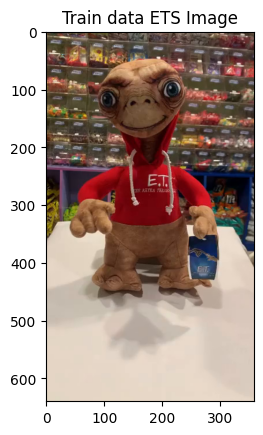

In [5]:
img_train=mpimg.imread("data/train/ETs/another_et_another_et001.png")
plt.title('Train data ETS Image')
img_plot=plt.imshow(img_train)
plt.show()

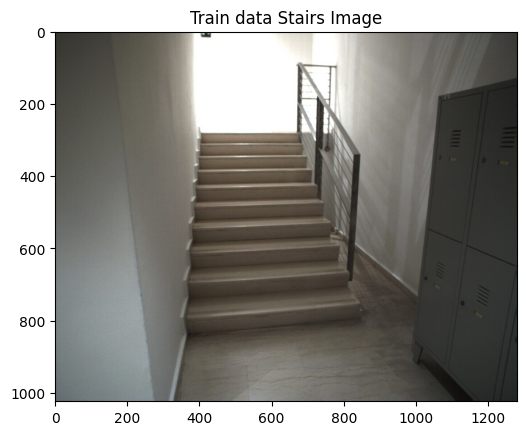

In [6]:
img_train=mpimg.imread("data/train/stairs/stairs_split_1_1710453576271.png")
plt.title('Train data Stairs Image')
img_plot=plt.imshow(img_train)
plt.show()

## **Load and Extract image**

In [ ]:
def load_image(path):
    return cv2.imread(path, cv2.IMREAD_COLOR)

def extract_orb_features(image):
    orb = cv2.ORB_create(nfeatures=1000)
    keypoints, descriptors = orb.detectAndCompute(image, None)
    return keypoints, descriptors

def flatten_descriptors(desc, size=128):  # Fixed-length for clustering
    if desc is None:
        return np.zeros(size)
    desc = desc.flatten()
    if len(desc) >= size:
        return desc[:size]
    else:
        return np.pad(desc, (0, size - len(desc)))

## **Match image in folder**

In [ ]:
def match_orb_features(des1, des2):
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    return matches

def visualize_matches(img1, kp1, img2, kp2, matches, top_n=100):
    matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:top_n], None, flags=2)
    plt.figure(figsize=(12, 6))
    plt.imshow(matched_img)
    plt.axis('off')
    plt.title("Top Image Matches")
    plt.show()

def match_images_in_folder(folder_path):
    image_paths = sorted(glob.glob(os.path.join(folder_path, "*.png")))
    
    if len(image_paths) < 2:
        print("Need at least two images to match.")
        return

    img1 = load_image(image_paths[0])
    img2 = load_image(image_paths[1])

    kp1, des1 = extract_orb_features(img1)
    kp2, des2 = extract_orb_features(img2)

    if des1 is None or des2 is None:
        print("Descriptors missing in one or both images.")
        return

    matches = match_orb_features(des1, des2)
    print(f"Found {len(matches)} matches between the first two images.")

    visualize_matches(img1, kp1, img2, kp2, matches)

In [ ]:
IMAGE_DIRS = ['data/train/ETs', 'data/train/stairs']  # Add more if needed
N_FEATURES = 1000
EPS = 0.5
MIN_SAMPLES = 3
DUMMY_TRANSLATION = "0.0;0.0;0.0"
DUMMY_ROTATION = "1.0;0.0;0.0;0.0;1.0;0.0;0.0;0.0;1.0"

image_records= []
features= []
for folder in IMAGE_DIRS:
    dataset = folder.split('/')[-1]
    image_paths = sorted(glob.glob(os.path.join(folder, '*.png')))

    for img_path in tqdm(image_paths):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        des = extract_orb_features(img)
        feature_vec = flatten_descriptors(des, size=128)
        features.append(feature_vec)

        image_records.append({
            'image': os.path.basename(img_path),
            'dataset': dataset,
            'path': img_path
        })

features = np.array(features)

print("Running DBSCAN clustering...")
clustering = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(features)
labels = clustering.labels_

for i in range(len(image_records)):
    image_records[i]['pred_scene'] = int(labels[i])
    image_records[i]['translation_vector'] = DUMMY_TRANSLATION
    image_records[i]['rotation_matrix'] = DUMMY_ROTATION

df_pred = pd.DataFrame(image_records)
df_pred[['image', 'dataset', 'pred_scene', 'translation_vector', 'rotation_matrix']].to_csv("your_predictions.csv", index=False)

print("✅ your_predictions.csv saved successfully!")

## **Similar image test for stairs**

Found 221 matches between the first two images.


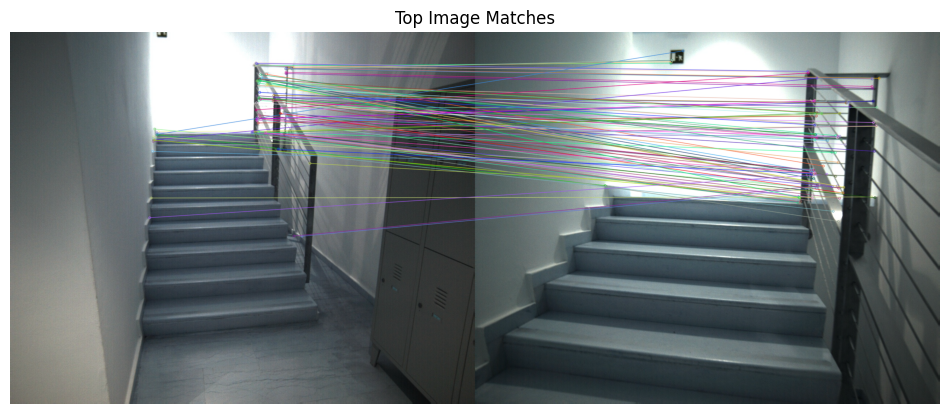

In [9]:
match_images_in_folder('data/test/stairs/')

## **Similar image test for ETs**

Found 403 matches between the first two images.


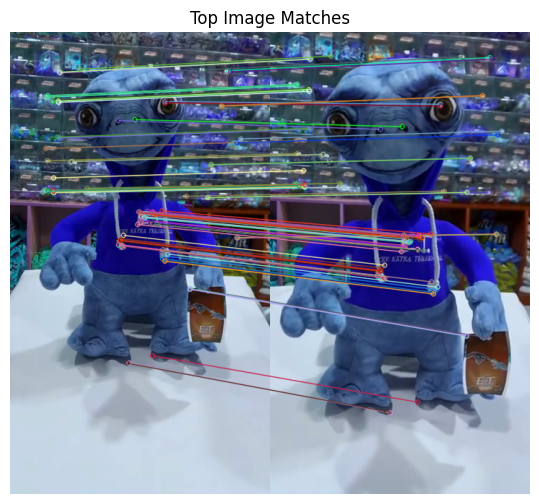

In [10]:
match_images_in_folder('data/test/ETs/')

## **Similar gardens test**

Found 245 matches between the first two images.


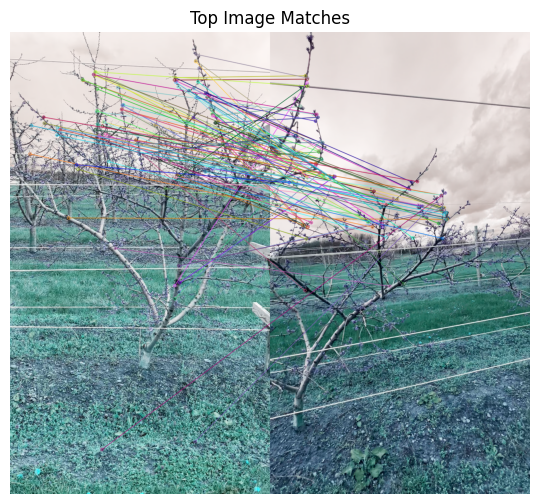

In [11]:
match_images_in_folder('data/train/amy_gardens/')